# Distributional Analysis of the Emotions "Freude" and "Wut" in German Corpora (DWDS)

An academic project focused on linguistic analysis and text data mining using 6 subcorpora from the **DWDS** (Digitales Wörterbuch der deutschen Sprache) platform.

## What does this project do?
* **Data Cleaning:** Tokenization, stopword removal, and special character filtering tailored for the German language (using NLTK and Re).
* **Collocation Analysis:** Extracting the most frequent word co-occurrences within a specific context window.
* **Embeddings (Word2Vec):** Training a word vector model (using Gensim) to explore the semantic proximity of emotions.
* **Clustering (K-Means & PCA):** Clustering emotional concepts and visualizing them in a 2D space.

### Legal Note and Data
In compliance with the DWDS license, the raw text data (`.tsv`, `.xlsx`) **is not included in this public repository**. This project contains only the original processing code.

## Analysis Results (Visualization)
To facilitate visualization - without the need to download the necessary corpora, or prior to doing - so visualization results and result tables appear in Markdown format following certain code blocks.

In [ ]:
import pandas as pd

In [ ]:
zeitungskorpora_freude = pd.read_csv("Berliner_Zeitung_94-05_Freude.tsv", sep='\t')
zeitungskorpora_freude

In [ ]:
webkorpora_freude = pd.read_csv("Webkorpora_Blogs_95-14_Freude.tsv", sep='\t')
webkorpora_freude

In [ ]:
metakorpora_freude = pd.read_csv("Metakorpora_DTA_Freude.tsv", sep='\t')
metakorpora_freude

In [ ]:
zeitungskorpora_wut = pd.read_csv("Berliner_Zeitung_94-05_Wut.tsv", sep='\t')
zeitungskorpora_wut

In [ ]:
webkorpora_wut = pd.read_csv("Webkorpora_Blogs_95-14_Wut.tsv", sep='\t')
webkorpora_wut

In [ ]:
metakorpora_wut = pd.read_csv("Metakorpora_DTA_Wut.tsv", sep='\t')
metakorpora_wut

In [ ]:
zeitungskorpora_freude.to_excel('zeitungskorpora_freude.xlsx')
webkorpora_freude.to_excel('webkorpora_freude.xlsx')
metakorpora_freude.to_excel('metakorpora_freude.xlsx')
zeitungskorpora_wut.to_excel('zeitungskorpora_wut.xlsx')
webkorpora_wut.to_excel('webkorpora_wut.xlsx')
metakorpora_wut.to_excel('metakorpora_wut.xlsx')

In [ ]:
import pandas as pd

zeitungskorpora_freude = pd.read_excel('zeitungskorpora_freude.xlsx')
webkorpora_freude = pd.read_excel('webkorpora_freude.xlsx')
metakorpora_freude = pd.read_excel('metakorpora_freude.xlsx')
zeitungskorpora_wut = pd.read_excel('zeitungskorpora_wut.xlsx')
webkorpora_wut = pd.read_excel('webkorpora_wut.xlsx')
metakorpora_wut = pd.read_excel('metakorpora_wut.xlsx')

In [ ]:
print(zeitungskorpora_freude.columns) 

In [ ]:
zeitungskorpora_freude['full_text'] = zeitungskorpora_freude['ContextBefore'] + ' ' + zeitungskorpora_freude['Hit'] + ' ' + zeitungskorpora_freude['ContextAfter']
webkorpora_freude['full_text'] = webkorpora_freude['ContextBefore'] + ' ' + webkorpora_freude['Hit'] + ' ' + webkorpora_freude['ContextAfter']
metakorpora_freude['full_text'] = metakorpora_freude['ContextBefore'] + ' ' + metakorpora_freude['Hit'] + ' ' + metakorpora_freude['ContextAfter']

zeitungskorpora_wut['full_text'] = zeitungskorpora_wut['ContextBefore'] + ' ' + zeitungskorpora_wut['Hit'] + ' ' + zeitungskorpora_wut['ContextAfter']
webkorpora_wut['full_text'] = webkorpora_wut['ContextBefore'] + ' ' + webkorpora_wut['Hit'] + ' ' + webkorpora_wut['ContextAfter']
metakorpora_wut['full_text'] = metakorpora_wut['ContextBefore'] + ' ' + metakorpora_wut['Hit'] + ' ' + metakorpora_wut['ContextAfter']

In [ ]:
print(zeitungskorpora_freude.columns) 

In [ ]:
import re
import spacy
from nltk.corpus import stopwords

nlp = spacy.load("de_core_news_sm")

try:
    stop_words = set(stopwords.words('german'))
except LookupError:
    import nltk
    nltk.download('stopwords')
    stop_words = set(stopwords.words('german'))

def clean_text(text):
    if pd.isnull(text):
        return []
    
    text = text.lower() 
    text = re.sub(r'[^a-zäöüß\s]', '', text)
    
    doc = nlp(text)
    
    tokens = [token.text for token in doc if token.text not in stop_words and token.text.strip() != '' and not token.is_punct]

    return tokens

# Przykład zastosowania na korpusie
zeitungskorpora_freude['tokens'] = zeitungskorpora_freude['full_text'].apply(clean_text)
# webkorpora_freude['tokens'] = webkorpora_freude['full_text'].apply(clean_text)
# metakorpora_freude['tokens'] = metakorpora_freude['full_text'].apply(clean_text)
# zeitungskorpora_wut['tokens'] = zeitungskorpora_wut['full_text'].apply(clean_text)
# webkorpora_wut['tokens'] = webkorpora_wut['full_text'].apply(clean_text)
# metakorpora_wut['tokens'] = metakorpora_wut['full_text'].apply(clean_text)
print(zeitungskorpora_freude['tokens'].head())

In [ ]:
zeitungskorpora_freude['tokens'] = zeitungskorpora_freude['full_text'].apply(clean_text)
webkorpora_freude['tokens'] = webkorpora_freude['full_text'].apply(clean_text)
metakorpora_freude['tokens'] = metakorpora_freude['full_text'].apply(clean_text)

zeitungskorpora_wut['tokens'] = zeitungskorpora_wut['full_text'].apply(clean_text)
webkorpora_wut['tokens'] = webkorpora_wut['full_text'].apply(clean_text)
metakorpora_wut['tokens'] = metakorpora_wut['full_text'].apply(clean_text)

In [ ]:
zeitungskorpora_freude.to_excel('zeitungskorpora_freude_cleaned.xlsx', index=False)
webkorpora_freude.to_excel('webkorpora_freude_cleaned.xlsx', index=False)
metakorpora_freude.to_excel('metakorpora_freude_cleaned.xlsx', index=False)

zeitungskorpora_wut.to_excel('zeitungskorpora_wut_cleaned.xlsx', index=False)
webkorpora_wut.to_excel('webkorpora_wut_cleaned.xlsx', index=False)
metakorpora_wut.to_excel('metakorpora_wut_cleaned.xlsx', index=False)

*collocation analisis*

In [ ]:
from collections import Counter

def find_collocations(tokenized_sentences, target_word, window=5):
    collocations = []
    
    for sentence in tokenized_sentences:
        for i, token in enumerate(sentence):
            if token == target_word:
                start = max(0, i - window)
                end = min(len(sentence), i + window + 1)
                collocations.extend(sentence[start:i] + sentence[i+1:end])
    
    return collocations

freude_collocations_zeitung = find_collocations(zeitungskorpora_freude['tokens'].tolist(), 'freude')
wut_collocations_zeitung = find_collocations(zeitungskorpora_wut['tokens'].tolist(), 'wut')

freude_collocations_web = find_collocations(webkorpora_freude['tokens'].tolist(), 'freude')
wut_collocations_web = find_collocations(webkorpora_wut['tokens'].tolist(), 'wut')

freude_collocations_meta = find_collocations(metakorpora_freude['tokens'].tolist(), 'freude')
wut_collocations_meta = find_collocations(metakorpora_wut['tokens'].tolist(), 'wut')

# Zliczanie najczęstszych kolokacji dla każdego korpusu
freude_counter_zeitung = Counter(freude_collocations_zeitung)
wut_counter_zeitung = Counter(wut_collocations_zeitung)

freude_counter_web = Counter(freude_collocations_web)
wut_counter_web = Counter(wut_collocations_web)

freude_counter_meta = Counter(freude_collocations_meta)
wut_counter_meta = Counter(wut_collocations_meta)

print("========== Freude - Zeitung (10 Most frequent collocations) ==========")
print(freude_counter_zeitung.most_common(10))
print()

print("========== Wut - Zeitung (10 Most frequent collocations) ==========")
print(wut_counter_zeitung.most_common(10))
print()

print("========== Freude - Web (10 Most frequent collocations) ==========")
print(freude_counter_web.most_common(10))
print()

print("========== Wut - Web (10 Most frequent collocations) ==========")
print(wut_counter_web.most_common(10))
print()

print("========== Freude - Meta (10 Most frequent collocations) ==========")
print(freude_counter_meta.most_common(10))
print()

print("========== Wut - Meta (10 Most frequent collocations) ==========")
print(wut_counter_meta.most_common(10))

In [ ]:
import pandas as pd
import spacy

nlp = spacy.load("de_core_news_sm")

zeitungskorpora_freude = pd.read_excel('zeitungskorpora_freude_cleaned.xlsx')
webkorpora_freude = pd.read_excel('webkorpora_freude_cleaned.xlsx')
metakorpora_freude = pd.read_excel('metakorpora_freude_cleaned.xlsx')

zeitungskorpora_wut = pd.read_excel('zeitungskorpora_wut_cleaned.xlsx')
webkorpora_wut = pd.read_excel('webkorpora_wut_cleaned.xlsx')
metakorpora_wut = pd.read_excel('metakorpora_wut_cleaned.xlsx')

zeitungskorpora_freude_cleaned = zeitungskorpora_freude.dropna(subset=['full_text'])
webkorpora_freude_cleaned = webkorpora_freude.dropna(subset=['full_text'])
metakorpora_freude_cleaned = metakorpora_freude.dropna(subset=['full_text'])

zeitungskorpora_wut_cleaned = zeitungskorpora_wut.dropna(subset=['full_text'])
webkorpora_wut_cleaned = webkorpora_wut.dropna(subset=['full_text'])
metakorpora_wut_cleaned = metakorpora_wut.dropna(subset=['full_text'])

def analysiere_syntax(texts):
    """
    Führt eine syntaktische Analyse durch und gibt grammatikalische Abhängigkeiten zurück.
    """
    doc = nlp(texts)
    satz_strukturen = []

    for sent in doc.sents:
        struktur = []
        for token in sent:
            struktur.append((token.text, token.dep_, token.head.text))
        satz_strukturen.append(struktur)

    return satz_strukturen

def analysiere_korpus(df, korpus_name):
    print(f"\n=== Analyse für: {korpus_name} ===")

    for idx, row in df.iterrows():
        text = row['full_text']
        if isinstance(text, str) and text.strip():
            ergebnis = analysiere_syntax(text)
            print(f"\n→ Satzstruktur für Dokument {idx+1}:")
            for satz in ergebnis:
                print(satz)
        else:
            print(f"\n⚠️ Leerer oder ungültiger Text in Zeile {idx+1}")

analysiere_korpus(zeitungskorpora_freude_cleaned, "Zeitung – Freude")
analysiere_korpus(webkorpora_freude_cleaned, "Web – Freude")
analysiere_korpus(metakorpora_freude_cleaned, "Metakorpus – Freude")

analysiere_korpus(zeitungskorpora_wut_cleaned, "Zeitung – Wut")
analysiere_korpus(webkorpora_wut_cleaned, "Web – Wut")
analysiere_korpus(metakorpora_wut_cleaned, "Metakorpus – Wut")

In [ ]:
def finde_typische_strukturen(df, zielwort):
    typische_saetze = []
    for idx, row in df.iterrows():
        text = row['full_text']
        if pd.isna(text) or not text.strip(): 
            continue
        doc = nlp(text)
        for sent in doc.sents:

            if any(token.text.lower() == zielwort.lower() for token in sent):
                struktur = [(t.text, t.dep_, t.head.text) for t in sent]
                typische_saetze.append(struktur)
            if len(typische_saetze) >= 5:  
                return typische_saetze
    return typische_saetze

korporen_info = [
    ("Zeitung – Freude", zeitungskorpora_freude, "Freude"),
    ("Zeitung – Wut", zeitungskorpora_wut, "Wut"),
    ("Web – Freude", webkorpora_freude, "Freude"),
    ("Web – Wut", webkorpora_wut, "Wut"),
    ("Meta – Freude", metakorpora_freude, "Freude"),
    ("Meta – Wut", metakorpora_wut, "Wut")
]

for name, df, zielwort in korporen_info:
    print(f"\n=== Typische Satzstrukturen: {name} ===\n")
    beispiele = finde_typische_strukturen(df, zielwort)
    if beispiele:
        for i, satz in enumerate(beispiele, 1):
            print(f"→ Beispiel {i}: {satz}")
    else:
        print("Keine typischen Strukturen gefunden.")

In [ ]:
import spacy
from collections import Counter

nlp = spacy.load("de_core_news_sm")

def dep_stats(df, zielwort):
    rollen = []
    verben = []
    
    zielwort_clean = zielwort.lower()
    
    for idx, row in df.iterrows():
        text = row['full_text']
        if pd.isna(text) or not text.strip():  # Pomija NaN oraz puste teksty
            continue
        doc = nlp(text)
        
        for token in doc:
            if token.text.lower() == zielwort_clean:  # Porównanie z oczyszczonym słowem kluczowym
                if token.dep_ and token.head:  # Sprawdzamy, czy token ma head i dep_
                    rollen.append(token.dep_)
                    verben.append(token.head.lemma_)
                    
    return Counter(rollen).most_common(5), Counter(verben).most_common(5)  # Top 5

korporen_info = [
    ("Zeitung – Freude", zeitungskorpora_freude, "Freude"),
    ("Zeitung – Wut", zeitungskorpora_wut, "Wut"),
    ("Web – Freude", webkorpora_freude, "Freude"),
    ("Web – Wut", webkorpora_wut, "Wut"),
    ("Meta – Freude", metakorpora_freude, "Freude"),
    ("Meta – Wut", metakorpora_wut, "Wut")
]

for name, df, zielwort in korporen_info:
    print(f"\n=== Syntaktische Rollen und Verben: {name} ===")
    rollen, verben = dep_stats(df, zielwort)
    print("Häufigste syntaktische Rollen:", rollen)
    print("Häufigste Verben (Kopf):", verben)

In [ ]:
import pandas as pd
from collections import Counter
import spacy
from IPython.display import display

nlp = spacy.load("de_core_news_sm")

def dep_stats(df, zielwort):
    rollen = []
    verben = []
    for idx, row in df.iterrows():
        text = str(row['full_text'])  
        if pd.isna(text) or not text.strip():  
            continue
        doc = nlp(text)
        for token in doc:
            if token.text.lower() == zielwort.lower():
                if token.head:  
                    rollen.append(token.dep_)
                    verben.append(token.head.lemma_)
    return Counter(rollen).most_common(5), Counter(verben).most_common(5)

korpora = [
    (zeitungskorpora_freude, "Freude", "Zeitung – Freude"),
    (zeitungskorpora_wut, "Wut", "Zeitung – Wut"),
    (webkorpora_freude, "Freude", "Web – Freude"),
    (webkorpora_wut, "Wut", "Web – Wut"),
    (metakorpora_freude, "Freude", "Meta – Freude"),
    (metakorpora_wut, "Wut", "Meta – Wut")
]

ergebnisse = []

for df, zielwort, name in korpora:
    rollen, verben = dep_stats(df, zielwort)
    rollen_str = ", ".join([r[0] for r in rollen])
    verben_str = ", ".join([v[0] for v in verben])
    ergebnisse.append({
        "Korpus": name,
        "Zielwort": zielwort,
        "Häufigste Rollen": rollen_str,
        "Häufigste Verben": verben_str
    })

tabelle = pd.DataFrame(ergebnisse)

print(tabelle)

tabelle.to_excel("syntaktische_strukturen.xlsx", index=False)

ergebnisse_df = pd.DataFrame(ergebnisse)

display(ergebnisse_df)

In [ ]:
import matplotlib.pyplot as plt

def plot_single(ax, counter, title):
    if len(counter) > 0:
        words, counts = zip(*counter.most_common(10))
        ax.barh(words, counts, color='skyblue')
        ax.invert_yaxis()
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Häufigkeit')

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

datasets = [
    (freude_counter_zeitung, 'Freude - Zeitungskorpora'),
    (freude_counter_web, 'Freude - Webkorpora'),
    (freude_counter_meta, 'Freude - Metakorpora'),
    (wut_counter_zeitung, 'Wut - Zeitungskorpora'),
    (wut_counter_web, 'Wut - Webkorpora'),
    (wut_counter_meta, 'Wut - Metakorpora'),
]

for ax, (counter, title) in zip(axes, datasets):
    plot_single(ax, counter, title)

plt.tight_layout()
plt.show()

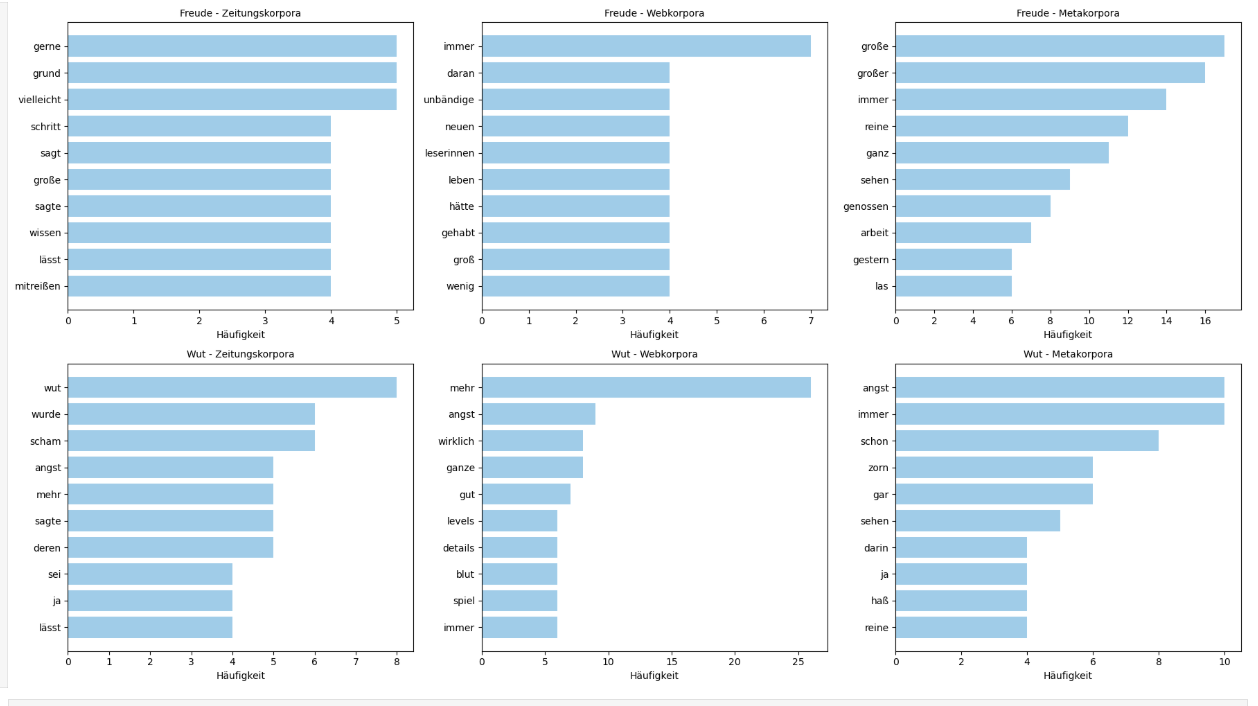

In [ ]:
def describe_collocations(counter, target_word, corpus_name):
    if len(counter) == 0:
        return f"Im Korpus {corpus_name} wurden keine Kollokationen für das Wort '{target_word}' gefunden.\n"
    
    most_common_word, most_common_count = counter.most_common(1)[0]
    total_collocations = sum(counter.values())
    unique_collocations = len(counter)
    
    description = (
        f"Im Korpus {corpus_name} für das Wort '{target_word}':\n"
        f"- Häufigste Kollokation: '{most_common_word}' ({most_common_count} Vorkommen)\n"
        f"- Gesamtzahl der Kollokationen: {total_collocations}\n"
        f"- Anzahl der einzigartigen Kollokationen: {unique_collocations}\n"
    )
    return description

print(describe_collocations(freude_counter_zeitung, 'Freude', 'Zeitungskorpora'))
print(describe_collocations(freude_counter_web, 'Freude', 'Webkorpora'))
print(describe_collocations(freude_counter_meta, 'Freude', 'Metakorpora'))

print(describe_collocations(wut_counter_zeitung, 'Wut', 'Zeitungskorpora'))
print(describe_collocations(wut_counter_web, 'Wut', 'Webkorpora'))
print(describe_collocations(wut_counter_meta, 'Wut', 'Metakorpora'))

In [ ]:
import pandas as pd
from collections import Counter

def describe_collocations(counter, target_word, corpus_name):
    if len(counter) == 0:
        return f"Im Korpus {corpus_name} wurden keine Kollokationen für das Wort '{target_word}' gefunden.\n"
    
    most_common_word, most_common_count = counter.most_common(1)[0]
    total_collocations = sum(counter.values())
    unique_collocations = len(counter)
    
    description = (
        f"Im Korpus {corpus_name} für das Wort '{target_word}':\n"
        f"- Häufigste Kollokation: '{most_common_word}' ({most_common_count} Vorkommen)\n"
        f"- Gesamtzahl der Kollokationen: {total_collocations}\n"
        f"- Anzahl der einzigartigen Kollokationen: {unique_collocations}\n"
    )
    
    data = {
        "Korpus": [corpus_name],
        "Zielwort": [target_word],
        "Häufigste Kollokation": [most_common_word],
        "Vorkommen der häufigsten Kollokation": [most_common_count],
        "Gesamtzahl der Kollokationen": [total_collocations],
        "Einzigartige Kollokationen": [unique_collocations]
    }
    
    df = pd.DataFrame(data)
    return df

results = []

results.append(describe_collocations(freude_counter_zeitung, 'Freude', 'Zeitungskorpora'))
results.append(describe_collocations(freude_counter_web, 'Freude', 'Webkorpora'))
results.append(describe_collocations(freude_counter_meta, 'Freude', 'Metakorpora'))

results.append(describe_collocations(wut_counter_zeitung, 'Wut', 'Zeitungskorpora'))
results.append(describe_collocations(wut_counter_web, 'Wut', 'Webkorpora'))
results.append(describe_collocations(wut_counter_meta, 'Wut', 'Metakorpora'))

final_df = pd.concat(results, ignore_index=True)

import IPython.display as display
display.display(final_df)

In [ ]:
import pandas as pd
import spacy
from gensim.models import Word2Vec

nlp = spacy.load("de_core_news_sm")

def tokenize_text(text):
    doc = nlp(text)
    return [token.text for token in doc if not token.is_stop and not token.is_punct]

freude_tokens_zeitung = [tokenize_text(text) for text in zeitungskorpora_freude['full_text'] if pd.notna(text)]
wut_tokens_zeitung = [tokenize_text(text) for text in zeitungskorpora_wut['full_text'] if pd.notna(text)]

freude_tokens_web = [tokenize_text(text) for text in webkorpora_freude['full_text'] if pd.notna(text)]
wut_tokens_web = [tokenize_text(text) for text in webkorpora_wut['full_text'] if pd.notna(text)]

freude_tokens_meta = [tokenize_text(text) for text in metakorpora_freude['full_text'] if pd.notna(text)]
wut_tokens_meta = [tokenize_text(text) for text in metakorpora_wut['full_text'] if pd.notna(text)]

all_sentences = (
    freude_tokens_zeitung + wut_tokens_zeitung + 
    freude_tokens_web + wut_tokens_web + 
    freude_tokens_meta + wut_tokens_meta
)

model = Word2Vec(sentences=all_sentences, vector_size=100, window=5, min_count=1, workers=4)

model.save("word2vec_gefühlswörter_all_korpora.model")

model = Word2Vec.load("word2vec_gefühlswörter_all_korpora.model")

similarity = model.wv.similarity('freude', 'wut')
print(f"Ähnlichkeit zwischen 'Freude' und 'Wut': {similarity}")
print()

similar_words_freude = model.wv.most_similar("freude", topn=10)
print("Die ähnlichsten Wörter zu 'Freude':", similar_words_freude)

similar_words_wut = model.wv.most_similar("wut", topn=10)
print("Die ähnlichsten Wörter zu 'Wut':", similar_words_wut)

for word in ['freude', 'wut']:
    similar_words = model.wv.most_similar(word, topn=10)
    print(f"\nDie ähnlichsten Wörter zu '{word}':")
    for similar_word, score in similar_words:
        print(f"{similar_word}: {score}")

similarity_results = {
    "Wort 1": ["Freude"],
    "Wort 2": ["Wut"],
    "Ähnlichkeit": [similarity]
}

similarity_df = pd.DataFrame(similarity_results)

freude_similar_df = pd.DataFrame(similar_words_freude, columns=["Wort", "Ähnlichkeit"])
wut_similar_df = pd.DataFrame(similar_words_wut, columns=["Wort", "Ähnlichkeit"])

import IPython.display as display
display.display(similarity_df)
display.display(freude_similar_df)
display.display(wut_similar_df)

In [ ]:
import pandas as pd
import spacy
from gensim.models import Word2Vec

nlp = spacy.load("de_core_news_sm")

def tokenize_text(text):
    doc = nlp(text)
    return [token.text.lower() for token in doc if not token.is_stop and not token.is_punct]  # Zamień na małe litery

freude_tokens_zeitung = [tokenize_text(text) for text in zeitungskorpora_freude['full_text'] if pd.notna(text)]
wut_tokens_zeitung = [tokenize_text(text) for text in zeitungskorpora_wut['full_text'] if pd.notna(text)]

freude_tokens_web = [tokenize_text(text) for text in webkorpora_freude['full_text'] if pd.notna(text)]
wut_tokens_web = [tokenize_text(text) for text in webkorpora_wut['full_text'] if pd.notna(text)]

freude_tokens_meta = [tokenize_text(text) for text in metakorpora_freude['full_text'] if pd.notna(text)]
wut_tokens_meta = [tokenize_text(text) for text in metakorpora_wut['full_text'] if pd.notna(text)]

all_sentences = (
    freude_tokens_zeitung + wut_tokens_zeitung + 
    freude_tokens_web + wut_tokens_web + 
    freude_tokens_meta + wut_tokens_meta
)

model = Word2Vec(sentences=all_sentences, vector_size=100, window=5, min_count=1, workers=4)

model.save("word2vec_gefühlswörter_all_korpora.model")

model = Word2Vec.load("word2vec_gefühlswörter_all_korpora.model")

for word in model.wv.index_to_key:  # Przeszukujemy cały słownik modelu
    similar_words = model.wv.most_similar(word, topn=5)  # Wybieramy 5 najbliższych słów
    print(f"\nDie ähnlichsten Wörter zu '{word}':")
    for similar_word, score in similar_words:
        print(f"{similar_word}: {score}")

In [ ]:
import pandas as pd
from IPython.display import display

# 7. Die ähnlichsten Wörter zu "freude"
similar_words_freude = model.wv.most_similar("freude", topn=10)
df_freude = pd.DataFrame(similar_words_freude, columns=["Ähnliches Wort", "Score"])
df_freude.insert(0, "Zielwort", "Freude")

# 7. Die ähnlichsten Wörter zu "wut"
similar_words_wut = model.wv.most_similar("wut", topn=10)
df_wut = pd.DataFrame(similar_words_wut, columns=["Ähnliches Wort", "Score"])
df_wut.insert(0, "Zielwort", "Wut")

# Anzeige beider Tabellen
print("Ähnlichste Wörter zu 'Freude':")
display(df_freude)

print("\nÄhnlichste Wörter zu 'Wut':")
display(df_wut)

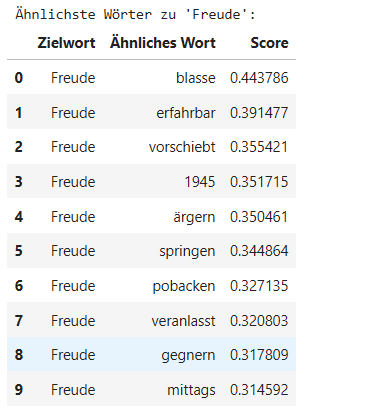 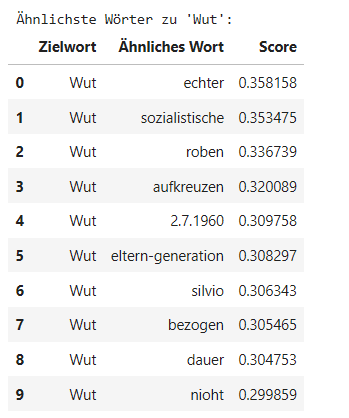

In [ ]:
import pandas as pd
from IPython.display import display

results_freude = []
results_wut = []

for word in ['freude', 'wut']:
    for korpus_name, korpus_tokens in [
        ("Zeitung", freude_tokens_zeitung + wut_tokens_zeitung),
        ("Web", freude_tokens_web + wut_tokens_web),
        ("Meta", freude_tokens_meta + wut_tokens_meta)]:
        
        temp_model = Word2Vec(sentences=korpus_tokens, vector_size=100, window=5, min_count=1, workers=4)
        temp_model.build_vocab(korpus_tokens, update=True)
        temp_model.train(korpus_tokens, total_examples=temp_model.corpus_count, epochs=10)

        try:
            similar_words = temp_model.wv.most_similar(word.lower(), topn=5)
            for similar_word, score in similar_words:
                row = {
                    "Zielwort": word.capitalize(),
                    "Korpus": korpus_name,
                    "Ähnliches Wort": similar_word,
                    "Score": score
                }
                if word == 'freude':
                    results_freude.append(row)
                else:
                    results_wut.append(row)
        except KeyError:
            print(f"'{word}' nicht im Vokabular von '{korpus_name}' gefunden.")

df_freude = pd.DataFrame(results_freude)
df_wut = pd.DataFrame(results_wut)

# Anzeige
print("Ähnlichste Wörter zu 'Freude' in den einzelnen Korpora:")
display(df_freude)

print("\nÄhnlichste Wörter zu 'Wut' in den einzelnen Korpora:")
display(df_wut)

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np

words = [word for word in model.wv.index_to_key if model.wv.get_vecattr(word, "count") >= 10]
word_vectors = np.array([model.wv[word] for word in words])

num_clusters = 5
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
kmeans.fit(word_vectors)

plt.figure(figsize=(10, 8))
for i in range(num_clusters):
    cluster_center = kmeans.cluster_centers_[i]
    plt.scatter(cluster_center[0], cluster_center[1], label=f'Cluster {i + 1}')

plt.title('K-Means Clustering of Words')
plt.legend()
plt.show()

In [ ]:
import pandas as pd

similarities_data = []

for word in ['freude', 'wut']:
    for korpus_name, korpus_tokens in [
        ("Zeitung", freude_tokens_zeitung + wut_tokens_zeitung),
        ("Web", freude_tokens_web + wut_tokens_web),
        ("Meta", freude_tokens_meta + wut_tokens_meta)]:
        
        temp_model = Word2Vec(sentences=korpus_tokens, vector_size=100, window=5, min_count=1, workers=4)
        temp_model.build_vocab(korpus_tokens, update=True)
        temp_model.train(korpus_tokens, total_examples=temp_model.corpus_count, epochs=10)

        try:
            similar_words = temp_model.wv.most_similar(word.lower(), topn=5)  # Wybieramy 5 najbliższych słów
            for similar_word, score in similar_words:
                similarities_data.append([word, korpus_name, similar_word, score])
        except KeyError:
            print(f"Das Wort '{word}' wurde nicht im Vokabular des Korpus '{korpus_name}' gefunden.")

df_similarities = pd.DataFrame(similarities_data, columns=["Word", "Corpus", "Similar Word", "Similarity Score"])

print(df_similarities)

df_similarities.to_csv('similarities_table.csv', index=False)

In [ ]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
reduced_vectors = pca.fit_transform(word_vectors)  # word_vectors = np.array([...])
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(word_vectors)

pca_df = pd.DataFrame({
    'Wort': words,
    'PCA1': reduced_vectors[:, 0],
    'PCA2': reduced_vectors[:, 1],
    'Cluster': clusters
})

from IPython.display import display
display(pca_df)

pca_df.to_csv("word2vec_clusters_pca.csv", index=False)

plt.figure(figsize=(10, 8))
for i in range(len(words)):
    plt.scatter(reduced_vectors[i][0], reduced_vectors[i][1], c=f"C{clusters[i]}")
    plt.text(reduced_vectors[i][0], reduced_vectors[i][1], words[i], fontsize=9)
plt.title('Visualisierung der K-means Ergebnisse von PCA')
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.grid(True)
plt.show()

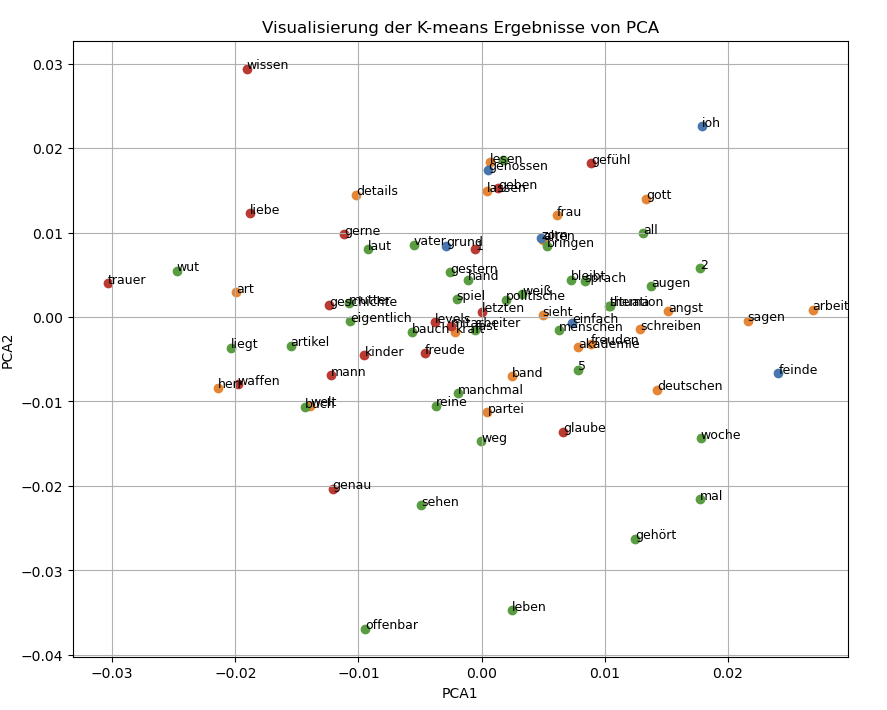

In [ ]:
from gensim.models import Word2Vec

all_sentences = (
    freude_tokens_zeitung + wut_tokens_zeitung + 
    freude_tokens_web + wut_tokens_web + 
    freude_tokens_meta + wut_tokens_meta
)

all_sentences = [[word for word in sentence if isinstance(word, str)] for sentence in all_sentences]

model = Word2Vec(sentences=all_sentences, vector_size=100, window=5, min_count=1, workers=4)

model.save("word2vec_gefühlsworter_all_korpora.model")

freude_similar = model.wv.most_similar('freude', topn=10)
wut_similar = model.wv.most_similar('wut', topn=10)

print("Die ähnlichsten Wörter zu 'Freude':")
for word, similarity in freude_similar:
    print(f"{word}: {similarity}")

print("\nDie ähnlichsten Wörter zu 'Wut':")
for word, similarity in wut_similar:
    print(f"{word}: {similarity}")

In [ ]:
similarity = model.wv.similarity('freude', 'wut')
print("\nSimilarity between 'Freude' and 'Wut':", similarity)

In [ ]:
import numpy as np
import pandas as pd
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

words = ['freude', 'wut'] + [word for word, _ in freude_similar] + [word for word, _ in wut_similar]
vectors = np.array([model.wv[word] for word in words])  # Wektory słów z modelu Word2Vec

tsne = TSNE(n_components=2, random_state=0, perplexity=5)
reduced_vectors = tsne.fit_transform(vectors)

tsne_df = pd.DataFrame({
    'Wort': words,
    'TSNE1': reduced_vectors[:, 0],
    'TSNE2': reduced_vectors[:, 1]
})

from IPython.display import display
display(tsne_df)

tsne_df.to_csv("tsne_word_vectors.csv", index=False)

plt.figure(figsize=(10, 8))
for i, word in enumerate(words):
    plt.scatter(reduced_vectors[i, 0], reduced_vectors[i, 1])
    plt.text(reduced_vectors[i, 0] + 0.01, reduced_vectors[i, 1] + 0.01, word, fontsize=12)

plt.title("Visualization of the word vectors for 'Freude' and 'Wut' and their similarities")
plt.show()

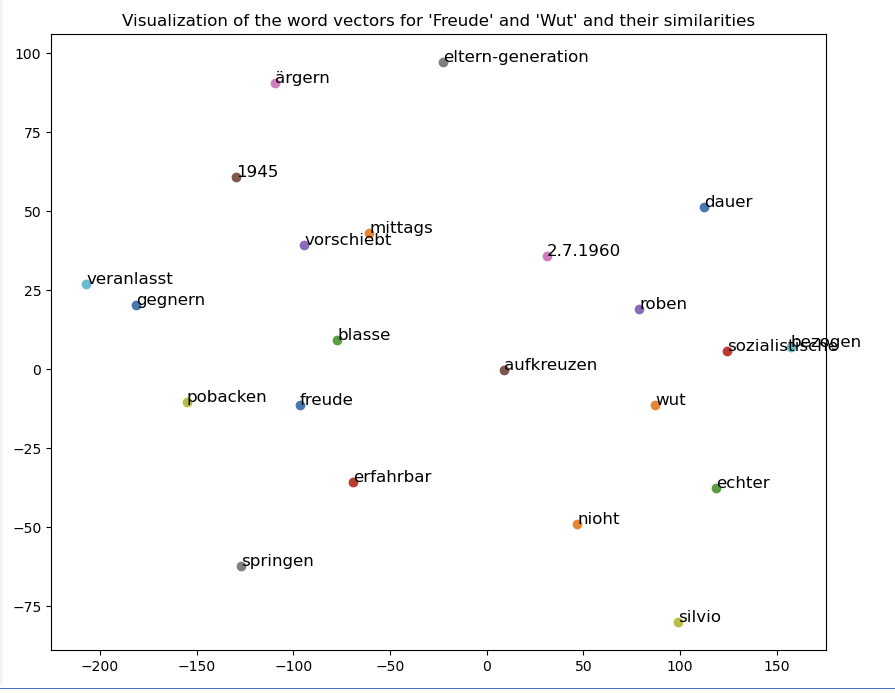

In [ ]:
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np

# Vorbereitung der Daten: Vektoren aller Wörter im Word2Vec-Modell
words = list(model.wv.index_to_key)
word_vectors = np.array([model.wv[word] for word in words])

# KMeans - Gruppierung der Wörter in 5 Cluster
kmeans = KMeans(n_clusters=5, random_state=0).fit(word_vectors)

# Zuweisung der Wörter zu Clustern und Extraktion der Ergebnisse
clusters = {}
for i, label in enumerate(kmeans.labels_):
    clusters.setdefault(label, []).append(words[i])

# Erstellen eines DataFrame mit den Ergebnissen
cluster_df = pd.DataFrame(columns=["Cluster", "Wörter"])
for cluster, terms in clusters.items():
    # Nur die ersten 10 Wörter jedes Clusters anzeigen
    cluster_df = pd.concat([cluster_df, pd.DataFrame({"Cluster": [cluster], "Wörter": [", ".join(terms[:10])]})], ignore_index=True)

# Anzeigen der Ergebnisse in einer Tabelle
print(cluster_df)

# Visualisierung in 2D - Dimensionsreduktion mit PCA
pca = PCA(n_components=2)
reduced = pca.fit_transform(word_vectors)

# Diagramm zeichnen
plt.figure(figsize=(10,7))
plt.scatter(reduced[:, 0], reduced[:, 1], c=kmeans.labels_, cmap='rainbow')
for i, word in enumerate(words):
    plt.annotate(word, xy=(reduced[i, 0], reduced[i, 1]), fontsize=8)
plt.title("Cluster of Emotions: Freude & Wut")
plt.show()

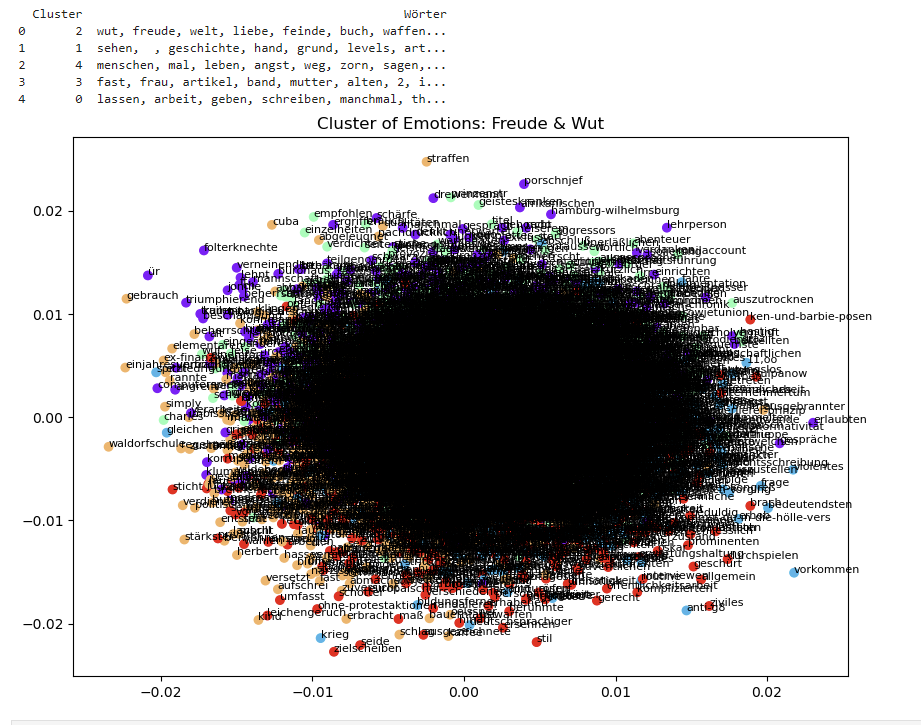

In [ ]:
kmeans = KMeans(n_clusters=10, random_state=0).fit(word_vectors)

In [ ]:
word_vectors_filtered = [model.wv[word] for word in words if model.wv.get_vecattr(word, "count") > 1]
words_filtered = [word for word in words if model.wv.get_vecattr(word, "count") > 1]

In [ ]:
tsne = TSNE(n_components=2, random_state=0, perplexity=30, max_iter=5000)
reduced_vectors = tsne.fit_transform(word_vectors)

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

plt.scatter(reduced_vectors[:, 0], reduced_vectors[:, 1], c=kmeans.labels_, cmap='rainbow')

for i, word in enumerate(words):
    plt.annotate(word, xy=(reduced_vectors[i, 0], reduced_vectors[i, 1]), fontsize=8)

plt.title("2D Visualization of Words (t-SNE) with Clusters")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.show()

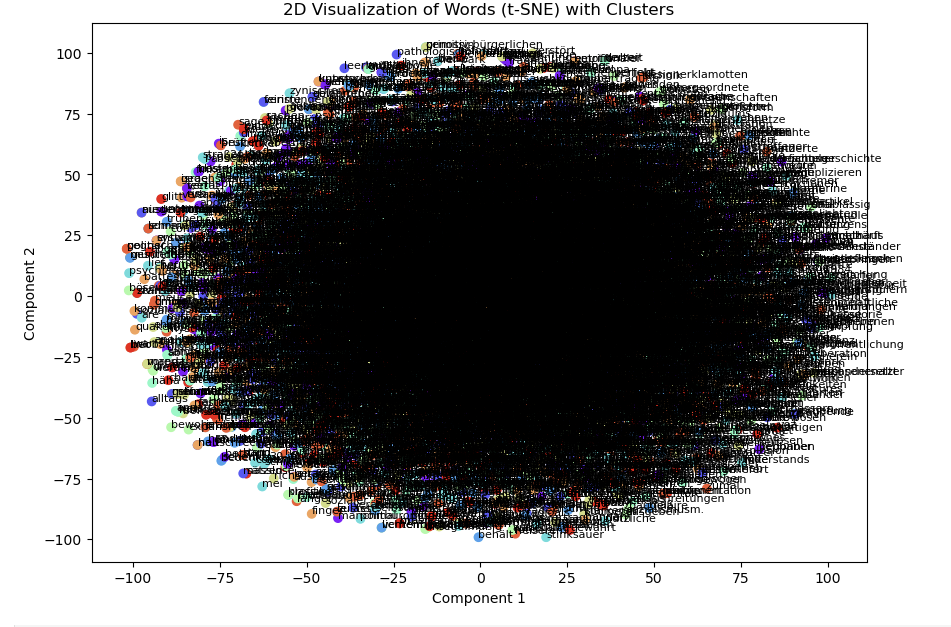

In [ ]:
import pandas as pd
import numpy as np

cluster_labels = kmeans.labels_

df_clusters = pd.DataFrame({
    'Word': words,
    'Cluster': cluster_labels
})

df_clusters_sorted = df_clusters.sort_values(by='Cluster')

print(df_clusters_sorted)

df_clusters_sorted.to_excel('Cluster_Results.xlsx', index=False)

In [ ]:
import pandas as pd
import nltk
from nltk.tokenize import word_tokenize

freude_zeitung = pd.read_excel("zeitungskorpora_freude_cleaned.xlsx")
wut_zeitung = pd.read_excel("zeitungskorpora_wut_cleaned.xlsx")

freude_web = pd.read_excel("webkorpora_freude_cleaned.xlsx")
wut_web = pd.read_excel("webkorpora_wut_cleaned.xlsx")

freude_meta = pd.read_excel("metakorpora_freude_cleaned.xlsx")
wut_meta = pd.read_excel("metakorpora_wut_cleaned.xlsx")

def tokenize_column(df, col_name="full_text"):
    combined_text = " ".join(df[col_name].astype(str)).lower()
    return word_tokenize(combined_text)

tokens_zeitung = tokenize_column(freude_zeitung) + tokenize_column(wut_zeitung)
tokens_web = tokenize_column(freude_web) + tokenize_column(wut_web)
tokens_meta = tokenize_column(freude_meta) + tokenize_column(wut_meta)

freude_zeitung_count = tokens_zeitung.count("freude")
wut_zeitung_count = tokens_zeitung.count("wut")

freude_web_count = tokens_web.count("freude")
wut_web_count = tokens_web.count("wut")

freude_meta_count = tokens_meta.count("freude")
wut_meta_count = tokens_meta.count("wut")

data = {
    'Korpus': ['Zeitung', 'Web', 'Meta'],
    'Freude': [freude_zeitung_count, freude_web_count, freude_meta_count],
    'Wut': [wut_zeitung_count, wut_web_count, wut_meta_count]
}

df_counts = pd.DataFrame(data)
print(df_counts)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

data = {
    'Korpus': ['Zeitung', 'Web', 'Meta'],
    'Freude': [90, 88, 102],
    'Wut': [101, 96, 105]
}

import pandas as pd
df = pd.DataFrame(data)
df_melted = df.melt(id_vars='Korpus', var_name='Wort', value_name='Häufigkeit')

plt.figure(figsize=(8,5))
sns.barplot(data=df_melted, x='Korpus', y='Häufigkeit', hue='Wort')
plt.title('Frequency of „Freude“ and „Wut“ in Various Corpora')
plt.ylabel('Number of occurrences')
plt.xlabel('Corpus')
plt.tight_layout()
plt.show()

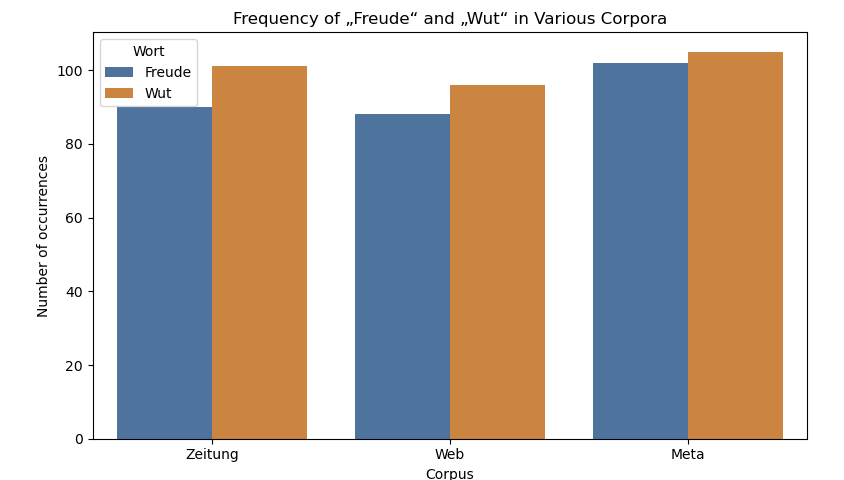

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from collections import Counter

freude_zeitung_collocations = {
    'gerne': 5, 'grund': 5, 'vielleicht': 5, 'schritt': 4, 'sagt': 4,
    'große': 4, 'sagte': 4, 'wissen': 4, 'lässt': 4, 'mitreißen': 4
}

wut_zeitung_collocations = {
    'wut': 8, 'wurde': 6, 'scham': 6, 'angst': 5, 'mehr': 5,
    'sagte': 5, 'deren': 5, 'sei': 4, 'ja': 4, 'lässt': 4
}

freude_web_collocations = {
    'immer': 7, 'daran': 4, 'unbändige': 4, 'neuen': 4, 'leserinnen': 4,
    'leben': 4, 'hätte': 4, 'gehabt': 4, 'groß': 4, 'wenig': 4
}

wut_web_collocations = {
    'mehr': 26, 'angst': 9, 'wirklich': 8, 'ganze': 8, 'gut': 7,
    'levels': 6, 'details': 6, 'blut': 6, 'spiel': 6, 'immer': 6
}

freude_meta_collocations = {
    'große': 17, 'großer': 16, 'immer': 14, 'reine': 12, 'ganz': 11,
    'sehen': 9, 'genossen': 8, 'arbeit': 7, 'gestern': 6, 'las': 6
}

wut_meta_collocations = {
    'angst': 10, 'immer': 10, 'schon': 8, 'zorn': 6, 'gar': 6,
    'sehen': 5, 'darin': 4, 'ja': 4, 'haß': 4, 'reine': 4
}

freude_collocations = {**freude_zeitung_collocations, **freude_web_collocations, **freude_meta_collocations}
wut_collocations = {**wut_zeitung_collocations, **wut_web_collocations, **wut_meta_collocations}

def generate_wordcloud(collocations, title):
    wc = WordCloud(background_color='white').generate_from_frequencies(collocations)
    plt.figure(figsize=(6, 6))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(title)
    plt.show()

generate_wordcloud(freude_collocations, 'Typical collocations for „Freude“')

generate_wordcloud(wut_collocations, 'TTypical collocations for „Wut“')

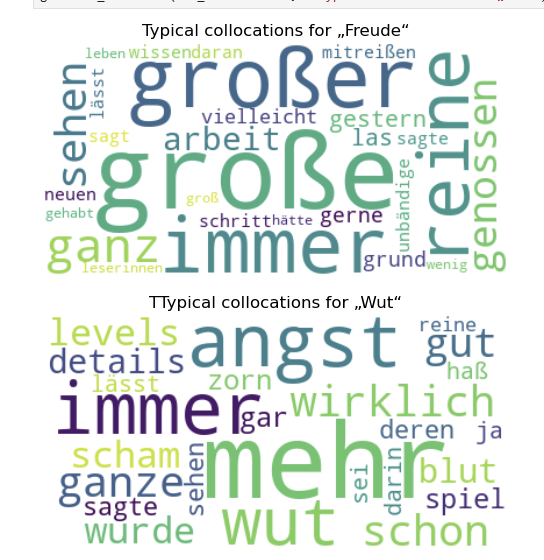

In [ ]:
freude_collocations_zeitung = ['gerne', 'grund', 'vielleicht', 'schritt', 'sagt', 'große', 'sagte', 'wissen', 'lässt', 'mitreißen']
wut_collocations_zeitung = ['wut', 'mehr', 'zorn', 'angst', 'laut', 'scham', 'wurde', 'sagte', 'deren', 'sei']

freude_collocations_web = ['immer', 'daran', 'unbändige', 'neuen', 'leserinnen', 'leben', 'hätte', 'gehabt', 'groß', 'wenig']
wut_collocations_web = ['mehr', 'angst', 'wirklich', 'ganze', 'gut', 'levels', 'details', 'blut', 'spiel', 'immer']

freude_collocations_meta = ['große', 'großer', 'immer', 'reine', 'ganz', 'sehen', 'genossen', 'arbeit', 'gestern', 'las']
wut_collocations_meta = ['angst', 'immer', 'schon', 'zorn', 'gar', 'sehen', 'darin', 'ja', 'haß', 'reine']

In [ ]:
from gensim.models import Word2Vec

def generate_fake_vectors(tokens):
    return np.random.rand(len(tokens), 300) 

freude_zeitung_vectors = generate_fake_vectors(freude_collocations_zeitung)
wut_zeitung_vectors = generate_fake_vectors(wut_collocations_zeitung)
freude_web_vectors = generate_fake_vectors(freude_collocations_web)
wut_web_vectors = generate_fake_vectors(wut_collocations_web)
freude_meta_vectors = generate_fake_vectors(freude_collocations_meta)
wut_meta_vectors = generate_fake_vectors(wut_collocations_meta)

all_vectors = np.concatenate([freude_zeitung_vectors, wut_zeitung_vectors,
                              freude_web_vectors, wut_web_vectors,
                              freude_meta_vectors, wut_meta_vectors], axis=0)

collocations = (freude_collocations_zeitung + wut_collocations_zeitung +
                freude_collocations_web + wut_collocations_web +
                freude_collocations_meta + wut_collocations_meta)

In [ ]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

pca = PCA(n_components=2)
reduced = pca.fit_transform(all_vectors)

kmeans = KMeans(n_clusters=2, random_state=0)
labels = kmeans.fit_predict(all_vectors)

plt.figure(figsize=(10,8))
sns.scatterplot(x=reduced[:,0], y=reduced[:,1], hue=labels, s=100)
for i, word in enumerate(collocations):
    plt.text(reduced[i,0]+0.01, reduced[i,1]+0.01, word, fontsize=9)
plt.title('Semantic clusters of collocations to „Freude“ and „Wut“ (PCA + KMeans)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.show()

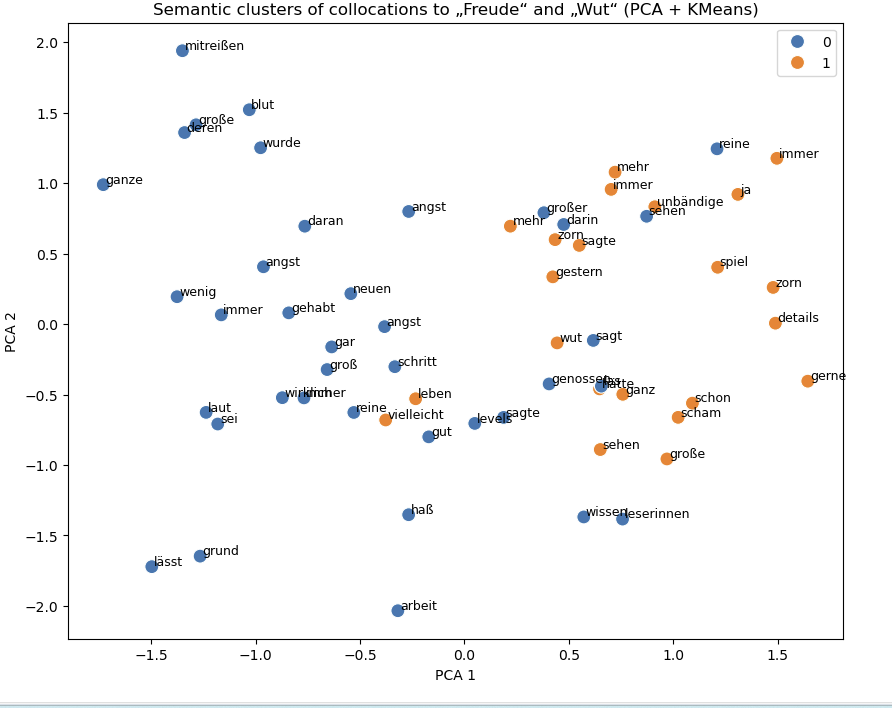

In [ ]:
from gensim.models import Word2Vec
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sentences = [["freude", "glück", "strahlen", "lachen", "wut", "zorn", "hass", "ärger", "trauer", "emotion"]]
model = Word2Vec(sentences, vector_size=100, window=5, min_count=1, workers=1)

freude_similar = model.wv.most_similar("freude", topn=5)
wut_similar = model.wv.most_similar("wut", topn=5)

words = ["freude"] + [w[0] for w in freude_similar] + ["wut"] + [w[0] for w in wut_similar]
labels = ["freude"] * (1 + len(freude_similar)) + ["wut"] * (1 + len(wut_similar))

vectors = np.array([model.wv[word] for word in words])

pca = PCA(n_components=2)
reduced = pca.fit_transform(vectors)

kmeans = KMeans(n_clusters=2, random_state=0, n_init=10)
clusters = kmeans.fit_predict(vectors)

plt.figure(figsize=(10, 7))
palette = sns.color_palette("Set1", n_colors=2)
sns.scatterplot(x=reduced[:, 0], y=reduced[:, 1], hue=clusters, s=120, palette=palette)
for i, word in enumerate(words):
    plt.text(reduced[i, 0]+0.01, reduced[i, 1]+0.01, word, fontsize=12)
plt.title('K-Means clusters of similar words „Freude“ and „Wut“')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Componente 2')
plt.legend(title="Cluster")
plt.grid(True)
plt.tight_layout()
plt.show()

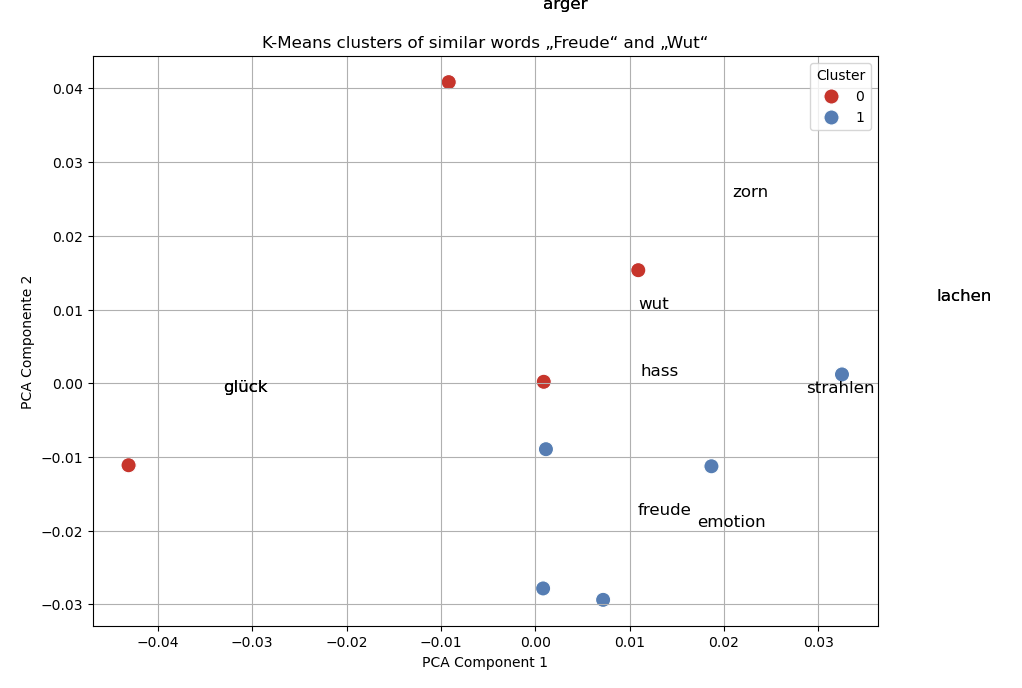